In [347]:
from bs4 import BeautifulSoup
# import pandas as pd
from datetime import datetime, timedelta
from itertools import combinations
import json
import requests
import math
from typing import Optional, List, Dict
import os

from pydantic import BaseModel
from typing import Mapping
import numpy as np
import polars as pl
import hvplot.polars
import pandas as pd
import altair as alt
import math

from shared.utils import formalize_data_with_str
from shared.random_rules import RandomRules

In [348]:
rr = RandomRules(
  TOTAL_NUMBERS = 50,
  CHOOSE = 6,
  MAX_PRIMES = 3,
  N_VALUES=["1", "2", "3"],
  # Rangos de valores de las bolillas
  MIN_B_VALUES = [1, 2, 3, 4, 5, 6],
  MAX_B_VALUES = [45, 46, 47, 48, 49, 50]
)

In [349]:
url = 'https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

tables = soup.select('table')
rows = tables[1].find_all('tr')

In [350]:
lst = []
post_str_b1 = None
post_str_b2 = None
post_str_b3 = None
post_str_b4 = None
post_str_b5 = None
post_str_blast = None
for row in rows:
  cols = [data.text.strip() for data in row.find_all('td')]
  
  id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=cols[2])
  cols.append(id)
  cols.append(bolillas_int)
  cols.extend([b for b in bolillas_int])
  cols.extend(str_combo)
  cols.append(post_str_b1)
  cols.append(post_str_b2)
  cols.append(post_str_b3)
  cols.append(post_str_b4)
  cols.append(post_str_b5)
  cols.append(post_str_blast)

  is_rare, reason = rr.is_rare_combination(bolillas_int, id)
  cols.append(is_rare)
  cols.append(reason)

  cols.append(rr.jumps_map(bolillas_int))
  cols.append(rr.unijump(bolillas_int))
  cols.append(rr.prime_counter(bolillas_int))
  cols.append(rr.evens_counter(bolillas_int))
  cols.append(rr.odds_counter(bolillas_int))

  jumps = rr.jumps(bolillas_int)
  cols.append(jumps[0])
  cols.append(jumps[1])
  cols.append(jumps[2])
  cols.append(jumps[3])
  cols.append(jumps[4])
  sum_jumps = sum(jumps)
  cols.append(sum(jumps))
  cols.append(sum([1 for j in jumps if j > 9]))
  cols.append(len(list(set(jumps))))
  cols.append(int(any([b == sum_jumps for b in bolillas_int])))
  
  lst.append(cols)

  post_str_b1 = str_combo[0]
  post_str_b2 = str_combo[1]
  post_str_b3 = str_combo[2]
  post_str_b4 = str_combo[3]
  post_str_b5 = str_combo[4]
  post_str_blast = str_combo[-1]

with open('./gn_tnk_v3.json', 'w') as file: 
  json.dump(lst, file)

dfRows = pl.DataFrame(
  lst,
  schema=[
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra',
    'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
    'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
    'post_str_b1', 'post_str_b2', 'post_str_b3', 'post_str_b4', 'post_str_b5', 'post_str_blast',
    'is_rare_combination', 'reason',
    "jumps_map", "unijump",
    "primes_count", "evens_count", "odds_count",
    "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff", "hjsum"
  ],
  schema_overrides={
    'combo': pl.Array(pl.UInt8, 6),
    'b1': pl.UInt8,
    'b2': pl.UInt8,
    'b3': pl.UInt8,
    'b4': pl.UInt8,
    'b5': pl.UInt8,
    'b6': pl.UInt8,
    'reason': pl.UInt8,

    'primes_count': pl.String,
    'evens_count': pl.String,
    'odds_count': pl.String,
    "j1": pl.String,
    "j2": pl.String,
    "j3": pl.String,
    "j4": pl.String,
    "j5": pl.String,
    "jsum": pl.String,
    "joor": pl.String,
    "jdiff": pl.String,
    "jsum": pl.String,
    "hjsum": pl.String
  },
  orient='row'
)

TOTAL_LINES = len(dfRows)
print(f'{TOTAL_LINES=}')
display(dfRows.head(10))
dfRows.write_parquet('dfrows_tnk.parquet')

TOTAL_LINES=2549


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""25/01/2026""","""1267""","""04 19 28 08 35 43""","""11""","""""","""""","""040819283543""","[4, 8, … 43]",4,8,19,28,35,43,"""04""","""08""","""19""","""28""","""35""","""43""",null,null,null,null,null,null,false,0,"""04_11_09_07_08""",-6,"""2""","""3""","""3""","""4""","""11""","""9""","""7""","""8""","""39""","""1""","""5""","""0"""
"""21/01/2026""","""1266""","""45 27 15 01 31 21""","""44""","""03 41 50 32""","""Promoción Sí o Sí""","""011521273145""","[1, 15, … 45]",1,15,21,27,31,45,"""01""","""15""","""21""","""27""","""31""","""45""","""04""","""08""","""19""","""28""","""35""","""43""",true,10,"""14_06_06_04_14""",24,"""1""","""0""","""6""","""14""","""6""","""6""","""4""","""14""","""44""","""2""","""3""","""0"""
"""18/01/2026""","""1265""","""01 28 31 37 11 09""","""26""","""08 50""","""Promoción Sí o Sí""","""010911283137""","[1, 9, … 37]",1,9,11,28,31,37,"""01""","""09""","""11""","""28""","""31""","""37""","""01""","""15""","""21""","""27""","""31""","""45""",false,0,"""08_02_17_03_06""",96,"""3""","""1""","""5""","""8""","""2""","""17""","""3""","""6""","""36""","""1""","""5""","""0"""
"""14/01/2026""","""1264""","""33 18 42 07 20 12""","""22""","""28 21""","""Promoción Sí o Sí""","""071218203342""","[7, 12, … 42]",7,12,18,20,33,42,"""07""","""12""","""18""","""20""","""33""","""42""","""01""","""09""","""11""","""28""","""31""","""37""",false,0,"""05_06_02_13_09""",-50,"""1""","""4""","""2""","""5""","""6""","""2""","""13""","""9""","""35""","""1""","""5""","""0"""
"""11/01/2026""","""1263""","""38 28 17 40 35 05""","""11""","""49 19""","""Promoción Sí o Sí""","""051728353840""","[5, 17, … 40]",5,17,28,35,38,40,"""05""","""17""","""28""","""35""","""38""","""40""","""07""","""12""","""18""","""20""","""33""","""42""",false,0,"""12_11_07_03_02""",0,"""2""","""3""","""3""","""12""","""11""","""7""","""3""","""2""","""35""","""2""","""5""","""1"""
"""07/01/2026""","""1262""","""05 34 26 02 09 47""","""40""","""35 27 49""","""Promoción Sí o Sí""","""020509263447""","[2, 5, … 47]",2,5,9,26,34,47,"""02""","""05""","""09""","""26""","""34""","""47""","""05""","""17""","""28""","""35""","""38""","""40""",true,16,"""03_04_17_08_13""",70,"""3""","""3""","""3""","""3""","""4""","""17""","""8""","""13""","""45""","""2""","""5""","""0"""
"""04/01/2026""","""1261""","""23 49 26 48 39 21""","""01""","""30""","""Promoción Sí o Sí""","""212326394849""","[21, 23, … 49]",21,23,26,39,48,49,"""21""","""23""","""26""","""39""","""48""","""49""","""02""","""05""","""09""","""26""","""34""","""47""",false,0,"""02_03_13_09_01""",33,"""1""","""2""","""4""","""2""","""3""","""13""","""9""","""1""","""28""","""1""","""5""","""0"""
"""31/12/2025""","""1260""","""38 35 44 47 37 28""","""45""","""03 49""","""Promoción Sí o Sí""","""283537384447""","[28, 35, … 47]",28,35,37,38,44,47,"""28""","""35""","""37""","""38""","""44""","""47""","""21""","""23""","""26""","""39""","""48""","""49""",true,16,"""07_02_01_06_03""",-16,"""2""","""3""","""3""","""7""","""2""","""1""","""6""","""3""","""19""","""0""","""5""","""0"""
"""28/12/2025""","""1259""","""06 13 31 22 11 16""","""19""","""15 10""","""Promoción Sí o Sí""","""061113162231""","[6, 11, … 31]",6,11,13,16,22,31,"""06""","""11""","""13""","""16""","""22""","""31""","""28""","""35""","""37""","""38""","""44""","""47""",false,0,"""05_02_03_06_09""",0,"""3""","""3""","""3""","""5""","""2""","""3""","""6""","""9""","""25""","""0""","""5""","""0"""


In [351]:
dfRows.filter(
  pl.col("b1") > 10
)

fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""04/01/2026""","""1261""","""23 49 26 48 39 21""","""01""","""30""","""Promoción Sí o Sí""","""212326394849""","[21, 23, … 49]",21,23,26,39,48,49,"""21""","""23""","""26""","""39""","""48""","""49""","""02""","""05""","""09""","""26""","""34""","""47""",false,0,"""02_03_13_09_01""",33,"""1""","""2""","""4""","""2""","""3""","""13""","""9""","""1""","""28""","""1""","""5""","""0"""
"""31/12/2025""","""1260""","""38 35 44 47 37 28""","""45""","""03 49""","""Promoción Sí o Sí""","""283537384447""","[28, 35, … 47]",28,35,37,38,44,47,"""28""","""35""","""37""","""38""","""44""","""47""","""21""","""23""","""26""","""39""","""48""","""49""",true,16,"""07_02_01_06_03""",-16,"""2""","""3""","""3""","""7""","""2""","""1""","""6""","""3""","""19""","""0""","""5""","""0"""
"""14/12/2025""","""1255""","""19 37 50 27 35 14""","""39""","""08""","""Promoción Sí o Sí""","""141927353750""","[14, 19, … 50]",14,19,27,35,37,50,"""14""","""19""","""27""","""35""","""37""","""50""","""10""","""12""","""13""","""14""","""25""","""39""",true,8,"""05_08_08_02_13""",26,"""2""","""2""","""4""","""5""","""8""","""8""","""2""","""13""","""36""","""1""","""4""","""0"""
"""07/12/2025""","""1253""","""45 46 32 28 11 43""","""35""","""10 02""","""Promoción Sí o Sí""","""112832434546""","[11, 28, … 46]",11,28,32,43,45,46,"""11""","""28""","""32""","""43""","""45""","""46""","""07""","""21""","""36""","""38""","""47""","""48""",false,0,"""17_04_11_02_01""",60,"""2""","""3""","""3""","""17""","""4""","""11""","""2""","""1""","""35""","""2""","""5""","""0"""
"""03/12/2025""","""1252""","""29 25 28 43 12 33""","""27""","""31 26 34 37""","""Promoción Sí o Sí""","""122528293343""","[12, 25, … 43]",12,25,28,29,33,43,"""12""","""25""","""28""","""29""","""33""","""43""","""11""","""28""","""32""","""43""","""45""","""46""",false,0,"""13_03_01_04_10""",1,"""2""","""2""","""4""","""13""","""3""","""1""","""4""","""10""","""31""","""2""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""10/09/1995""","""0048""","""11 19 20 21 24 36""","""""","""""","""""","""111920212436""","[11, 19, … 36]",11,19,20,21,24,36,"""11""","""19""","""20""","""21""","""24""","""36""","""10""","""13""","""17""","""21""","""23""","""32""",true,8,"""08_01_01_03_12""",10,"""2""","""3""","""3""","""8""","""1""","""1""","""3""","""12""","""25""","""1""","""4""","""0"""
"""23/07/1995""","""0041""","""14 18 21 25 29 30""","""""","""""","""""","""141821252930""","[14, 18, … 30]",14,18,21,25,29,30,"""14""","""18""","""21""","""25""","""29""","""30""","""03""","""04""","""06""","""10""","""16""","""29""",true,8,"""04_03_04_04_01""",1,"""1""","""3""","""3""","""4""","""3""","""4""","""4""","""1""","""16""","""0""","""3""","""0"""
"""09/04/1995""","""0026""","""16 18 24 25 29 31""","""""","""""","""""","""161824252931""","[16, 18, … 31]",16,18,24,25,29,31,"""16""","""18""","""24""","""25""","""29""","""31""","""01""","""03""","""19""","""27""","""30""","""35""",false,0,"""02_06_01_04_02""",-30,"""2""","""3""","""3""","""2""","""6""","""1""","""4""","""2""","""15""","""0""","""4""","""0"""


In [352]:

def count_column (df: pl.DataFrame, col_name: str, k: int = None) -> None:
  df_viz = (df if k == None else df[0:k]) \
    .group_by(
      col_name
    ).agg(pl.count(col_name).alias('count')) \
    .sort("count", descending=True)

  chart = df_viz.hvplot.bar(
    x=col_name,
    y='count'
  )

  chart.opts(default_tools=["pan"])
  display(chart)
  return df_viz[col_name].to_list()

jjsum = count_column(dfRows, 'hjsum', 200)
jdiff_count = count_column(dfRows, 'jdiff', 200)

j1_count = count_column(dfRows, 'j1', 200)
j2_count = count_column(dfRows, 'j2', 200)
j3_count = count_column(dfRows, 'j3', 200)
j4_count = count_column(dfRows, 'j4', 200)
j5_count = count_column(dfRows, 'j5', 200)

joor_count = count_column(dfRows, "joor", 200)
primes_count = count_column(dfRows, 'primes_count', 200)
evens_count = count_column(dfRows, 'evens_count', 200)
odds_count = count_column(dfRows, 'odds_count', 200)

jsums = count_column(dfRows, 'jsum', 200)
# print(jsums[0:22])



:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [353]:
dfRows.item(0, 'b2')

8

In [354]:
import holoviews as hv
def plot_post_col (col: str, post_col: str, test_value: str | None = None):
  if test_value == None:
    test_value = dfRows.item(0, col)
    print(f'Setting {test_value=}')

  df_viz = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      post_col
    ).agg(pl.count(post_col).alias('count')) \
    .sort("count", descending=True)
  
  
  df_10_last = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .head(10)
  
  # Agrega una columna que sea el porcentaje de la frecuencia relativa
  total = df_viz['count'].sum()
  df_viz = df_viz.with_columns(
    ( (pl.col('count') / total) * 100 ).alias('percent')
  )

  mean_percent = df_viz['percent'].mean()
  mean_percent_75 = mean_percent * 75 / 50
  mean_percent_25 = mean_percent * 25 / 50

  chart = df_viz.hvplot.bar(
    x=post_col,
    y='percent'
  )

  chart = chart * hv.HLine(mean_percent).opts(color='red')
  chart = chart * hv.HLine(mean_percent_75).opts(color='blue')
  chart = chart * hv.HLine(mean_percent_25).opts(color='blue')
  
  chart.opts(default_tools=["pan"])

  df_jumps_map = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'jumps_map'
    ).agg(pl.count('jumps_map').alias('count')) \
    .sort("count", descending=True)
  
  df_unijump = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'unijump'
    ).agg(pl.count('unijump').alias('count')) \
    .sort("count", descending=True)


  print(f'df_viz FOR {col} = {test_value}')
  display(df_viz)

  display(chart)
  

  print(f'df_10_last FOR {col} = {test_value}')
  last_results = list(set(df_10_last[post_col][0:3]))
  print(f'Last 3 results {last_results=}')
  display(df_10_last)
  
  print(f'df_jumps_map FOR {col} = {test_value}')
  display(df_jumps_map)
  # display(df_unijump)

  print(f'df_unijump FOR {col} = {test_value}')
  display(df_unijump)

  lst_post_str_b = df_viz.filter(pl.col('percent') >= mean_percent)[post_col].to_list()
  lst_jumps_map = df_jumps_map['jumps_map'].to_list() # Used to discard
  
  return lst_post_str_b, lst_jumps_map, last_results

In [355]:
possible_b1, exclude_jump_maps_b1, last_post_b1 = plot_post_col(col='str_b1', post_col='post_str_b1')

Setting test_value='04'
df_viz FOR str_b1 = 04


post_str_b1,count,percent
str,u32,f64
"""02""",32,14.414414
"""05""",26,11.711712
"""01""",23,10.36036
"""03""",22,9.90991
"""04""",20,9.009009
…,…,…
"""24""",2,0.900901
"""17""",1,0.45045
"""22""",1,0.45045


:Overlay
   .Bars.I    :Bars   [post_str_b1]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b1 = 04
Last 3 results last_results=['14', '02']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""16/11/2025""","""1247""","""15 04 46 41 44 10""","""03""","""18 31 13""","""Promoción Sí o Sí""","""041015414446""","[4, 10, … 46]",4,10,15,41,44,46,"""04""","""10""","""15""","""41""","""44""","""46""","""02""","""21""","""28""","""33""","""40""","""44""",true,16,"""06_05_26_03_02""",132,"""1""","""4""","""2""","""6""","""5""","""26""","""3""","""2""","""42""","""1""","""5""","""0"""
"""22/10/2025""","""1240""","""04 18 11 06 07 45""","""17""","""14 15""","""Promoción Sí o Sí""","""040607111845""","[4, 6, … 45]",4,6,7,11,18,45,"""04""","""06""","""07""","""11""","""18""","""45""","""02""","""12""","""15""","""17""","""32""","""46""",true,16,"""02_01_04_07_27""",21,"""2""","""3""","""3""","""2""","""1""","""4""","""7""","""27""","""41""","""1""","""5""","""0"""
"""31/08/2025""","""1225""","""30 35 32 12 38 04""","""29""","""02""","""Promoción Sí o Sí""","""041230323538""","[4, 12, … 38]",4,12,30,32,35,38,"""04""","""12""","""30""","""32""","""35""","""38""","""14""","""15""","""18""","""21""","""23""","""48""",true,8,"""08_18_02_03_03""",-61,"""0""","""5""","""1""","""8""","""18""","""2""","""3""","""3""","""34""","""1""","""4""","""0"""
"""27/07/2025""","""1215""","""36 24 04 21 34 09""","""17""","""02""","""Promoción Sí o Sí""","""040921243436""","[4, 9, … 36]",4,9,21,24,34,36,"""04""","""09""","""21""","""24""","""34""","""36""","""01""","""03""","""09""","""25""","""28""","""43""",false,0,"""05_12_03_10_02""",-63,"""0""","""4""","""2""","""5""","""12""","""3""","""10""","""2""","""32""","""2""","""5""","""0"""
"""14/05/2025""","""1194""","""38 07 12 13 04 09""","""42""","""46 28""","""Promoción Sí o Sí""","""040709121338""","[4, 7, … 38]",4,7,9,12,13,38,"""04""","""07""","""09""","""12""","""13""","""38""","""09""","""11""","""13""","""15""","""33""","""42""",false,0,"""03_02_03_01_25""",34,"""2""","""3""","""3""","""3""","""2""","""3""","""1""","""25""","""34""","""1""","""4""","""0"""
"""19/03/2025""","""1178""","""32 41 42 37 34 04""","""48""","""07 46 19""","""Promoción Sí o Sí""","""043234374142""","[4, 32, … 42]",4,32,34,37,41,42,"""04""","""32""","""34""","""37""","""41""","""42""","""03""","""07""","""18""","""24""","""37""","""49""",false,0,"""28_02_03_04_01""",23,"""2""","""4""","""2""","""28""","""2""","""3""","""4""","""1""","""38""","""1""","""5""","""0"""
"""02/02/2025""","""1165""","""20 48 14 12 28 04""","""02""","""40""","""Promoción Sí o Sí""","""041214202848""","[4, 12, … 48]",4,12,14,20,28,48,"""04""","""12""","""14""","""20""","""28""","""48""","""12""","""19""","""24""","""27""","""30""","""33""",true,20,"""08_02_06_08_20""",24,"""0""","""6""","""0""","""8""","""2""","""6""","""8""","""20""","""44""","""1""","""4""","""0"""
"""15/12/2024""","""1151""","""48 26 45 08 06 04""","""44""","""15 29""","""Promoción Sí o Sí""","""040608264548""","[4, 6, … 48]",4,6,8,26,45,48,"""04""","""06""","""08""","""26""","""45""","""48""","""19""","""22""","""28""","""33""","""35""","""47""",true,24,"""02_02_18_19_03""",29,"""0""","""5""","""1""","""2""","""2""","""18""","""19""","""3""","""44""","""2""","""4""","""0"""
"""11/12/2024""","""1150""","""43 04 39 31 10 46""","""06""","""36 07 22""","""Promoción Sí o Sí""","""041031394346""","[4, 10, … 46]",4,10,31,39,43,46,"""04""","""10""","""31""","""39""","""43""","""46""","""04""","""06""","""08""","""26""","""45""","""48""",true,16,"""06_21_08_04_03""",-43,"""2""","""3""","""3""","""6""","""21""","""8""","""4""","""3""","""42""","""1""","""5""","""0"""


df_jumps_map FOR str_b1 = 04


jumps_map,count
str,u32
"""18_07_01_13_01""",1
"""03_03_02_15_01""",1
"""09_07_06_09_03""",1
"""16_06_09_01_01""",1
"""02_07_08_08_15""",1
…,…
"""07_01_08_02_05""",1
"""04_14_03_17_03""",1
"""10_01_11_06_05""",1


df_unijump FOR str_b1 = 04


unijump,count
i64,u32
24,5
-24,4
-9,4
12,4
34,4
…,…
-59,1
-36,1
27,1


In [356]:
possible_b2, exclude_jump_maps_b2, last_post_b2 = plot_post_col(col='str_b2', post_col='post_str_b2')

Setting test_value='08'
df_viz FOR str_b2 = 08


post_str_b2,count,percent
str,u32,f64
"""13""",11,7.38255
"""11""",11,7.38255
"""12""",11,7.38255
"""08""",9,6.040268
"""14""",8,5.369128
…,…,…
"""29""",2,1.342282
"""24""",2,1.342282
"""26""",2,1.342282


:Overlay
   .Bars.I    :Bars   [post_str_b2]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b2 = 08
Last 3 results last_results=['13', '19', '06']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""08/06/2025""","""1201""","""05 08 25 18 34 12""","""14""","""44""","""Promoción Sí o Sí""","""050812182534""","[5, 8, … 34]",5,8,12,18,25,34,"""05""","""08""","""12""","""18""","""25""","""34""","""15""","""19""","""20""","""22""","""38""","""39""",false,0,"""03_04_06_07_09""",4,"""1""","""4""","""2""","""3""","""4""","""6""","""7""","""9""","""29""","""0""","""5""","""0"""
"""27/04/2025""","""1189""","""46 33 21 08 07 41""","""39""","""36 09 37""","""Promoción Sí o Sí""","""070821334146""","[7, 8, … 46]",7,8,21,33,41,46,"""07""","""08""","""21""","""33""","""41""","""46""","""02""","""06""","""11""","""16""","""33""","""36""",false,0,"""01_13_12_08_05""",-6,"""2""","""2""","""4""","""1""","""13""","""12""","""8""","""5""","""39""","""2""","""5""","""0"""
"""23/02/2025""","""1171""","""10 44 30 05 08 36""","""25""","""47 02 23""","""Promoción Sí o Sí""","""050810303644""","[5, 8, … 44]",5,8,10,30,36,44,"""05""","""08""","""10""","""30""","""36""","""44""","""12""","""13""","""16""","""21""","""23""","""25""",true,16,"""03_02_20_06_08""",99,"""1""","""5""","""1""","""3""","""2""","""20""","""6""","""8""","""39""","""1""","""5""","""0"""
"""28/07/2024""","""1111""","""19 14 25 03 08 26""","""50""","""""","""""","""030814192526""","[3, 8, … 26]",3,8,14,19,25,26,"""03""","""08""","""14""","""19""","""25""","""26""","""07""","""12""","""22""","""28""","""29""","""37""",false,0,"""05_06_05_06_01""",-12,"""2""","""3""","""3""","""5""","""6""","""5""","""6""","""1""","""23""","""0""","""3""","""0"""
"""16/06/2024""","""1099""","""08 46 19 02 23 21""","""28""","""42 27""","""Promoción Sí o Sí""","""020819212346""","[2, 8, … 46]",2,8,19,21,23,46,"""02""","""08""","""19""","""21""","""23""","""46""","""09""","""15""","""21""","""27""","""31""","""37""",true,8,"""06_11_02_02_23""",-11,"""3""","""3""","""3""","""6""","""11""","""2""","""2""","""23""","""44""","""2""","""4""","""0"""
"""12/06/2024""","""1098""","""03 11 48 08 32 16""","""09""","""23""","""Promoción Sí o Sí""","""030811163248""","[3, 8, … 48]",3,8,11,16,32,48,"""03""","""08""","""11""","""16""","""32""","""48""","""02""","""08""","""19""","""21""","""23""","""46""",true,8,"""05_03_05_16_16""",-25,"""2""","""4""","""2""","""5""","""3""","""5""","""16""","""16""","""45""","""2""","""3""","""0"""
"""02/06/2024""","""1095""","""26 12 02 08 13 37""","""36""","""03 31 34""","""Promoción Sí o Sí""","""020812132637""","[2, 8, … 37]",2,8,12,13,26,37,"""02""","""08""","""12""","""13""","""26""","""37""","""09""","""14""","""21""","""22""","""24""","""33""",false,0,"""06_04_01_13_11""",-45,"""3""","""4""","""2""","""6""","""4""","""1""","""13""","""11""","""35""","""2""","""5""","""0"""
"""21/02/2024""","""1066""","""14 35 30 39 08 02""","""05""","""13 38 45""","""Promoción Sí o Sí""","""020814303539""","[2, 8, … 39]",2,8,14,30,35,39,"""02""","""08""","""14""","""30""","""35""","""39""","""05""","""14""","""31""","""35""","""40""","""45""",true,8,"""06_06_16_05_04""",62,"""1""","""4""","""2""","""6""","""6""","""16""","""5""","""4""","""37""","""1""","""4""","""0"""
"""08/11/2023""","""1036""","""35 02 11 41 19 08""","""07""","""03 14 36""","""Promoción Sí o Sí""","""020811193541""","[2, 8, … 41]",2,8,11,19,35,41,"""02""","""08""","""11""","""19""","""35""","""41""","""17""","""26""","""27""","""32""","""43""","""46""",true,1,"""06_03_08_16_06""",-16,"""4""","""2""","""4""","""6""","""3""","""8""","""16""","""6""","""39""","""1""","""4""","""0"""


df_jumps_map FOR str_b2 = 08


jumps_map,count
str,u32
"""01_08_04_02_15""",1
"""07_05_11_04_01""",1
"""01_15_04_05_11""",1
"""06_06_06_06_09""",1
"""02_03_01_11_05""",1
…,…
"""07_10_02_17_06""",1
"""06_09_02_19_03""",1
"""07_10_03_03_07""",1


df_unijump FOR str_b2 = 08


unijump,count
i64,u32
-30,4
10,4
-36,3
-1,3
-33,3
…,…
-83,1
1,1
92,1


In [357]:
possible_b3, exclude_jump_maps_b3, last_post_b3 = plot_post_col(col='str_b3', post_col='post_str_b3')

Setting test_value='19'
df_viz FOR str_b3 = 19


post_str_b3,count,percent
str,u32,f64
"""18""",10,7.874016
"""11""",9,7.086614
"""14""",8,6.299213
"""13""",8,6.299213
"""21""",8,6.299213
…,…,…
"""35""",2,1.574803
"""04""",1,0.787402
"""36""",1,0.787402


:Overlay
   .Bars.I    :Bars   [post_str_b3]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b3 = 19
Last 3 results last_results=['13', '21']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""20/07/2025""","""1213""","""42 45 28 06 19 05""","""10""","""37""","""Promoción Sí o Sí""","""050619284245""","[5, 6, … 45]",5,6,19,28,42,45,"""05""","""06""","""19""","""28""","""42""","""45""","""01""","""02""","""13""","""22""","""24""","""43""",true,16,"""01_13_09_14_03""",-50,"""2""","""3""","""3""","""1""","""13""","""9""","""14""","""3""","""40""","""2""","""5""","""0"""
"""07/07/2024""","""1105""","""07 22 34 20 19 09""","""32""","""17 02 35""","""Promoción Sí o Sí""","""070919202234""","[7, 9, … 34]",7,9,19,20,22,34,"""07""","""09""","""19""","""20""","""22""","""34""","""01""","""02""","""21""","""22""","""30""","""40""",false,0,"""02_10_01_02_12""",-28,"""2""","""3""","""3""","""2""","""10""","""1""","""2""","""12""","""27""","""2""","""4""","""0"""
"""16/06/2024""","""1099""","""08 46 19 02 23 21""","""28""","""42 27""","""Promoción Sí o Sí""","""020819212346""","[2, 8, … 46]",2,8,19,21,23,46,"""02""","""08""","""19""","""21""","""23""","""46""","""09""","""15""","""21""","""27""","""31""","""37""",true,8,"""06_11_02_02_23""",-11,"""3""","""3""","""3""","""6""","""11""","""2""","""2""","""23""","""44""","""2""","""4""","""0"""
"""17/03/2024""","""1073""","""17 19 13 41 34 24""","""26""","""18 22""","""Promoción Sí o Sí""","""131719243441""","[13, 17, … 41]",13,17,19,24,34,41,"""13""","""17""","""19""","""24""","""34""","""41""","""08""","""10""","""11""","""21""","""22""","""31""",true,1,"""04_02_05_10_07""",-7,"""4""","""2""","""4""","""4""","""2""","""5""","""10""","""7""","""28""","""1""","""5""","""0"""
"""11/02/2024""","""1063""","""19 41 01 31 27 12""","""44""","""35 05""","""Promoción Sí o Sí""","""011219273141""","[1, 12, … 41]",1,12,19,27,31,41,"""01""","""12""","""19""","""27""","""31""","""41""","""03""","""07""","""18""","""29""","""39""","""42""",false,0,"""11_07_08_04_10""",25,"""3""","""1""","""5""","""11""","""7""","""8""","""4""","""10""","""40""","""2""","""5""","""0"""
"""28/01/2024""","""1059""","""25 03 19 21 24 15""","""12""","""06""","""Promoción Sí o Sí""","""031519212425""","[3, 15, … 25]",3,15,19,21,24,25,"""03""","""15""","""19""","""21""","""24""","""25""","""04""","""13""","""21""","""22""","""34""","""48""",false,0,"""12_04_02_03_01""",-3,"""2""","""1""","""5""","""12""","""4""","""2""","""3""","""1""","""22""","""1""","""5""","""0"""
"""05/11/2023""","""1035""","""34 32 19 03 25 14""","""02""","""10 23 16 36""","""Promoción Sí o Sí""","""031419253234""","[3, 14, … 34]",3,14,19,25,32,34,"""03""","""14""","""19""","""25""","""32""","""34""","""02""","""08""","""11""","""19""","""35""","""41""",false,0,"""11_05_06_07_02""",1,"""2""","""3""","""3""","""11""","""5""","""6""","""7""","""2""","""31""","""1""","""5""","""0"""
"""16/08/2023""","""1012""","""37 19 13 26 45 02""","""32""","""25 33 38""","""Promoción Sí o Sí""","""021319263745""","[2, 13, … 45]",2,13,19,26,37,45,"""02""","""13""","""19""","""26""","""37""","""45""","""06""","""07""","""25""","""27""","""34""","""43""",true,1,"""11_06_07_11_08""",-7,"""4""","""2""","""4""","""11""","""6""","""7""","""11""","""8""","""43""","""2""","""4""","""0"""
"""25/06/2023""","""0997""","""19 26 23 25 02 11""","""03""","""37 14""","""Promoción Sí o Sí""","""021119232526""","[2, 11, … 26]",2,11,19,23,25,26,"""02""","""11""","""19""","""23""","""25""","""26""","""07""","""14""","""34""","""35""","""38""","""43""",true,1,"""09_08_04_02_01""",-6,"""4""","""2""","""4""","""9""","""8""","""4""","""2""","""1""","""24""","""0""","""5""","""0"""


df_jumps_map FOR str_b3 = 19


jumps_map,count
str,u32
"""03_15_08_02_01""",1
"""05_09_18_04_01""",1
"""01_01_05_17_03""",1
"""05_05_12_02_13""",1
"""01_15_05_05_14""",1
…,…
"""09_04_01_01_08""",1
"""04_05_03_04_02""",1
"""03_15_15_06_04""",1


df_unijump FOR str_b3 = 19


unijump,count
i64,u32
19,4
-35,4
13,3
21,3
4,3
…,…
-37,1
28,1
34,1


In [358]:
possible_b4, exclude_jump_maps_b4, last_post_b4 = plot_post_col(col='str_b4', post_col='post_str_b4')

Setting test_value='28'
df_viz FOR str_b4 = 28


post_str_b4,count,percent
str,u32,f64
"""24""",10,7.936508
"""33""",9,7.142857
"""29""",8,6.349206
"""27""",8,6.349206
"""25""",7,5.555556
…,…,…
"""34""",2,1.587302
"""35""",2,1.587302
"""30""",1,0.793651


:Overlay
   .Bars.I    :Bars   [post_str_b4]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b4 = 28
Last 3 results last_results=['27', '15', '22']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""18/01/2026""","""1265""","""01 28 31 37 11 09""","""26""","""08 50""","""Promoción Sí o Sí""","""010911283137""","[1, 9, … 37]",1,9,11,28,31,37,"""01""","""09""","""11""","""28""","""31""","""37""","""01""","""15""","""21""","""27""","""31""","""45""",false,0,"""08_02_17_03_06""",96,"""3""","""1""","""5""","""8""","""2""","""17""","""3""","""6""","""36""","""1""","""5""","""0"""
"""20/07/2025""","""1213""","""42 45 28 06 19 05""","""10""","""37""","""Promoción Sí o Sí""","""050619284245""","[5, 6, … 45]",5,6,19,28,42,45,"""05""","""06""","""19""","""28""","""42""","""45""","""01""","""02""","""13""","""22""","""24""","""43""",true,16,"""01_13_09_14_03""",-50,"""2""","""3""","""3""","""1""","""13""","""9""","""14""","""3""","""40""","""2""","""5""","""0"""
"""02/07/2025""","""1208""","""14 28 32 07 10 29""","""36""","""37 27 16""","""Promoción Sí o Sí""","""071014282932""","[7, 10, … 32]",7,10,14,28,29,32,"""07""","""10""","""14""","""28""","""29""","""32""","""03""","""11""","""14""","""15""","""20""","""29""",false,0,"""03_04_14_01_03""",70,"""2""","""4""","""2""","""3""","""4""","""14""","""1""","""3""","""25""","""1""","""4""","""0"""
"""18/06/2025""","""1204""","""26 45 28 09 24 50""","""14""","""07""","""Promoción Sí o Sí""","""092426284550""","[9, 24, … 50]",9,24,26,28,45,50,"""09""","""24""","""26""","""28""","""45""","""50""","""02""","""07""","""25""","""33""","""45""","""46""",true,24,"""15_02_02_17_05""",-44,"""0""","""4""","""2""","""15""","""2""","""2""","""17""","""5""","""41""","""2""","""4""","""0"""
"""05/03/2025""","""1174""","""01 32 03 12 28 47""","""20""","""49 06 23 24""","""Promoción Sí o Sí""","""010312283247""","[1, 3, … 47]",1,3,12,28,32,47,"""01""","""03""","""12""","""28""","""32""","""47""","""01""","""20""","""23""","""38""","""42""","""44""",false,0,"""02_09_16_04_15""",61,"""2""","""3""","""3""","""2""","""9""","""16""","""4""","""15""","""46""","""2""","""5""","""0"""
"""20/11/2024""","""1144""","""36 27 28 26 29 03""","""10""","""44 39 45""","""Promoción Sí o Sí""","""032627282936""","[3, 26, … 36]",3,26,27,28,29,36,"""03""","""26""","""27""","""28""","""29""","""36""","""05""","""19""","""26""","""29""","""45""","""46""",true,24,"""23_01_01_01_07""",28,"""2""","""3""","""3""","""23""","""1""","""1""","""1""","""7""","""33""","""1""","""3""","""0"""
"""23/10/2024""","""1136""","""28 09 16 01 46 40""","""50""","""37 41 27""","""Promoción Sí o Sí""","""010916284046""","[1, 9, … 46]",1,9,16,28,40,46,"""01""","""09""","""16""","""28""","""40""","""46""","""06""","""16""","""24""","""27""","""32""","""47""",true,24,"""08_07_12_12_06""",10,"""0""","""4""","""2""","""8""","""7""","""12""","""12""","""6""","""45""","""2""","""4""","""0"""
"""31/07/2024""","""1112""","""37 07 28 12 22 29""","""43""","""01 40 36 25""","""Promoción Sí o Sí""","""071222282937""","[7, 12, … 37]",7,12,22,28,29,37,"""07""","""12""","""22""","""28""","""29""","""37""","""02""","""17""","""36""","""38""","""41""","""43""",false,0,"""05_10_06_01_08""",5,"""3""","""3""","""3""","""5""","""10""","""6""","""1""","""8""","""30""","""1""","""5""","""0"""
"""24/07/2024""","""1110""","""23 32 28 19 38 25""","""40""","""03""","""Promoción Sí o Sí""","""192325283238""","[19, 23, … 38]",19,23,25,28,32,38,"""19""","""23""","""25""","""28""","""32""","""38""","""03""","""08""","""14""","""19""","""25""","""26""",false,0,"""04_02_03_04_06""",4,"""2""","""3""","""3""","""4""","""2""","""3""","""4""","""6""","""19""","""0""","""4""","""1"""


df_jumps_map FOR str_b4 = 28


jumps_map,count
str,u32
"""10_06_06_03_10""",1
"""06_01_12_02_03""",1
"""06_03_05_01_11""",1
"""03_11_12_15_03""",1
"""03_15_07_03_13""",1
…,…
"""01_02_11_13_03""",1
"""16_03_05_03_08""",1
"""06_14_06_02_10""",1


df_unijump FOR str_b4 = 28


unijump,count
i64,u32
4,4
20,4
11,3
1,3
-15,3
…,…
-29,1
33,1
27,1


In [359]:
possible_b5, exclude_jump_maps_b5, last_post_b5 = plot_post_col(col='str_b5', post_col='post_str_b5')

Setting test_value='35'
df_viz FOR str_b5 = 35


post_str_b5,count,percent
str,u32,f64
"""32""",10,7.142857
"""37""",9,6.428571
"""35""",9,6.428571
"""40""",8,5.714286
"""25""",8,5.714286
…,…,…
"""11""",1,0.714286
"""20""",1,0.714286
"""21""",1,0.714286


:Overlay
   .Bars.I    :Bars   [post_str_b5]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b5 = 35
Last 3 results last_results=['37', '39', '23']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""28/09/2025""","""1233""","""24 17 31 09 35 44""","""33""","""03 11""","""Promoción Sí o Sí""","""091724313544""","[9, 17, … 44]",9,17,24,31,35,44,"""09""","""17""","""24""","""31""","""35""","""44""","""10""","""13""","""14""","""36""","""37""","""41""",true,8,"""08_07_07_04_09""",15,"""2""","""2""","""4""","""8""","""7""","""7""","""4""","""9""","""35""","""0""","""4""","""1"""
"""14/09/2025""","""1229""","""35 06 12 33 38 02""","""14""","""44 46""","""Promoción Sí o Sí""","""020612333538""","[2, 6, … 38]",2,6,12,33,35,38,"""02""","""06""","""12""","""33""","""35""","""38""","""14""","""19""","""24""","""34""","""39""","""44""",false,0,"""04_06_21_02_03""",101,"""1""","""4""","""2""","""4""","""6""","""21""","""2""","""3""","""36""","""1""","""5""","""0"""
"""31/08/2025""","""1225""","""30 35 32 12 38 04""","""29""","""02""","""Promoción Sí o Sí""","""041230323538""","[4, 12, … 38]",4,12,30,32,35,38,"""04""","""12""","""30""","""32""","""35""","""38""","""14""","""15""","""18""","""21""","""23""","""48""",true,8,"""08_18_02_03_03""",-61,"""0""","""5""","""1""","""8""","""18""","""2""","""3""","""3""","""34""","""1""","""4""","""0"""
"""09/07/2025""","""1210""","""35 28 09 42 31 16""","""45""","""50 23""","""Promoción Sí o Sí""","""091628313542""","[9, 16, … 42]",9,16,28,31,35,42,"""09""","""16""","""28""","""31""","""35""","""42""","""09""","""24""","""32""","""38""","""43""","""49""",false,0,"""07_12_03_04_07""",-32,"""1""","""3""","""3""","""7""","""12""","""3""","""4""","""7""","""33""","""1""","""4""","""0"""
"""04/05/2025""","""1191""","""09 35 19 15 37 10""","""46""","""25 02 38""","""Promoción Sí o Sí""","""091015193537""","[9, 10, … 37]",9,10,15,19,35,37,"""09""","""10""","""15""","""19""","""35""","""37""","""02""","""33""","""35""","""38""","""48""","""50""",true,16,"""01_05_04_16_02""",-57,"""2""","""1""","""5""","""1""","""5""","""4""","""16""","""2""","""28""","""1""","""5""","""0"""
"""09/02/2025""","""1167""","""34 03 46 35 33 12""","""18""","""44 06 41""","""Promoción Sí o Sí""","""031233343546""","[3, 12, … 46]",3,12,33,34,35,46,"""03""","""12""","""33""","""34""","""35""","""46""","""18""","""23""","""24""","""32""","""33""","""44""",true,8,"""09_21_01_01_11""",-62,"""1""","""3""","""3""","""9""","""21""","""1""","""1""","""11""","""43""","""2""","""4""","""0"""
"""18/12/2024""","""1152""","""22 28 33 19 47 35""","""44""","""13 32""","""Promoción Sí o Sí""","""192228333547""","[19, 22, … 47]",19,22,28,33,35,47,"""19""","""22""","""28""","""33""","""35""","""47""","""01""","""02""","""17""","""24""","""40""","""49""",false,0,"""03_06_05_02_12""",13,"""2""","""2""","""4""","""3""","""6""","""5""","""2""","""12""","""28""","""1""","""5""","""1"""
"""01/12/2024""","""1147""","""42 09 27 12 35 15""","""13""","""48 43 03 08""","""Promoción Sí o Sí""","""091215273542""","[9, 12, … 42]",9,12,15,27,35,42,"""09""","""12""","""15""","""27""","""35""","""42""","""02""","""17""","""20""","""29""","""36""","""38""",true,8,"""03_03_12_08_07""",38,"""0""","""2""","""4""","""3""","""3""","""12""","""8""","""7""","""33""","""1""","""4""","""0"""
"""13/11/2024""","""1142""","""49 19 35 09 17 18""","""45""","""34""","""Promoción Sí o Sí""","""091718193549""","[9, 17, … 49]",9,17,18,19,35,49,"""09""","""17""","""18""","""19""","""35""","""49""","""07""","""11""","""15""","""37""","""42""","""46""",true,24,"""08_01_01_16_14""",-40,"""2""","""1""","""5""","""8""","""1""","""1""","""16""","""14""","""40""","""2""","""4""","""0"""


df_jumps_map FOR str_b5 = 35


jumps_map,count
str,u32
"""03_08_12_03_08""",1
"""06_12_07_05_04""",1
"""11_10_07_03_08""",1
"""09_06_04_01_02""",1
"""13_03_05_13_04""",1
…,…
"""04_08_02_09_07""",1
"""04_06_21_02_03""",1
"""04_01_12_05_05""",1


df_unijump FOR str_b5 = 35


unijump,count
i64,u32
-45,4
1,4
35,3
-16,3
22,3
…,…
-30,1
-37,1
46,1


In [360]:
possible_blast, exclude_jump_maps_blast, last_post_blast = plot_post_col(col='str_b6', post_col='post_str_blast')

Setting test_value='43'
df_viz FOR str_b6 = 43


post_str_blast,count,percent
str,u32,f64
"""45""",28,11.666667
"""43""",27,11.25
"""44""",27,11.25
"""39""",20,8.333333
"""41""",19,7.916667
…,…,…
"""48""",1,0.416667
"""21""",1,0.416667
"""23""",1,0.416667


:Overlay
   .Bars.I    :Bars   [post_str_blast]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b6 = 43
Last 3 results last_results=['46', '31', '39']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""03/12/2025""","""1252""","""29 25 28 43 12 33""","""27""","""31 26 34 37""","""Promoción Sí o Sí""","""122528293343""","[12, 25, … 43]",12,25,28,29,33,43,"""12""","""25""","""28""","""29""","""33""","""43""","""11""","""28""","""32""","""43""","""45""","""46""",false,0,"""13_03_01_04_10""",1,"""2""","""2""","""4""","""13""","""3""","""1""","""4""","""10""","""31""","""2""","""5""","""0"""
"""09/11/2025""","""1245""","""18 43 29 32 21 17""","""13""","""04""","""Promoción Sí o Sí""","""171821293243""","[17, 18, … 43]",17,18,21,29,32,43,"""17""","""18""","""21""","""29""","""32""","""43""","""02""","""04""","""06""","""17""","""22""","""31""",false,0,"""01_03_08_03_11""",36,"""3""","""2""","""4""","""1""","""3""","""8""","""3""","""11""","""26""","""1""","""4""","""0"""
"""13/08/2025""","""1220""","""36 07 43 32 20 33""","""17""","""41 42""","""Promoción Sí o Sí""","""072032333643""","[7, 20, … 43]",7,20,32,33,36,43,"""07""","""20""","""32""","""33""","""36""","""43""","""07""","""11""","""26""","""27""","""34""","""39""",true,16,"""13_12_01_03_07""",-34,"""2""","""3""","""3""","""13""","""12""","""1""","""3""","""7""","""36""","""2""","""5""","""1"""
"""30/07/2025""","""1216""","""43 28 03 09 01 25""","""23""","""31""","""Promoción Sí o Sí""","""010309252843""","[1, 3, … 43]",1,3,9,25,28,43,"""01""","""03""","""09""","""25""","""28""","""43""","""02""","""14""","""23""","""41""","""45""","""46""",false,0,"""02_06_16_03_15""",77,"""2""","""1""","""5""","""2""","""6""","""16""","""3""","""15""","""42""","""2""","""5""","""0"""
"""23/07/2025""","""1214""","""22 13 24 43 02 01""","""21""","""49""","""Promoción Sí o Sí""","""010213222443""","[1, 2, … 43]",1,2,13,22,24,43,"""01""","""02""","""13""","""22""","""24""","""43""","""04""","""09""","""21""","""24""","""34""","""36""",false,0,"""01_11_09_02_19""",22,"""3""","""3""","""3""","""1""","""11""","""9""","""2""","""19""","""42""","""2""","""5""","""0"""
"""01/06/2025""","""1199""","""02 16 19 14 43 22""","""04""","""17 48 27""","""Promoción Sí o Sí""","""021416192243""","[2, 14, … 43]",2,14,16,19,22,43,"""02""","""14""","""16""","""19""","""22""","""43""","""01""","""05""","""21""","""30""","""36""","""50""",true,8,"""12_02_03_03_21""",31,"""3""","""4""","""2""","""12""","""2""","""3""","""3""","""21""","""41""","""2""","""4""","""0"""
"""26/03/2025""","""1180""","""43 01 05 37 35 13""","""39""","""38 07 45 16""","""Promoción Sí o Sí""","""010513353743""","[1, 5, … 43]",1,5,13,35,37,43,"""01""","""05""","""13""","""35""","""37""","""43""","""25""","""28""","""29""","""31""","""46""","""47""",true,19,"""04_08_22_02_06""",102,"""4""","""0""","""6""","""4""","""8""","""22""","""2""","""6""","""42""","""1""","""5""","""0"""
"""15/09/2024""","""1125""","""36 43 29 01 03 38""","""25""","""19 18 35 02""","""Promoción Sí o Sí""","""010329363843""","[1, 3, … 43]",1,3,29,36,38,43,"""01""","""03""","""29""","""36""","""38""","""43""","""10""","""21""","""26""","""32""","""34""","""37""",false,0,"""02_26_07_02_05""",-63,"""3""","""2""","""4""","""2""","""26""","""7""","""2""","""5""","""42""","""1""","""4""","""0"""
"""04/08/2024""","""1113""","""38 17 02 36 41 43""","""47""","""50 26""","""Promoción Sí o Sí""","""021736384143""","[2, 17, … 43]",2,17,36,38,41,43,"""02""","""17""","""36""","""38""","""41""","""43""","""10""","""14""","""18""","""32""","""36""","""38""",true,1,"""15_19_02_03_02""",-59,"""4""","""3""","""3""","""15""","""19""","""2""","""3""","""2""","""41""","""2""","""4""","""1"""


df_jumps_map FOR str_b6 = 43


jumps_map,count
str,u32
"""10_04_03_11_13""",1
"""05_16_01_04_07""",1
"""02_08_03_21_08""",1
"""06_07_05_05_05""",1
"""03_19_05_11_02""",1
…,…
"""03_26_03_01_08""",1
"""13_05_02_10_12""",1
"""17_03_01_12_06""",1


df_unijump FOR str_b6 = 43


unijump,count
i64,u32
16,5
22,5
1,5
11,4
39,4
…,…
13,1
107,1
123,1


In [361]:
b_count = rr.CHOOSE
min_b = rr.MIN_B_VALUES[0]
max_b = rr.MAX_B_VALUES[-1]


combos = combinations(range(min_b, max_b + 1), b_count)
# print("generating combos: ", len(list(combos)))

In [362]:
parquet_file = './parquet_tnk_v3.parquet'

# check if parquet_file exists
if not os.path.exists(parquet_file):
  print(f'{parquet_file=} does not exists. creating')
  lst = []
  post_str_b1 = None
  post_str_blast = None
  for row in combos:
    cols = []
    str_row = " ".join([str(r).zfill(2) for r in row])
    id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=str_row)
    cols.append(id)
    cols.append(bolillas_int)
    cols.extend([b for b in bolillas_int])
    cols.extend(str_combo)
    cols.append(post_str_b1)
    cols.append(post_str_blast)

    is_rare, reason = rr.is_rare_combination(bolillas_int, id)
    cols.append(is_rare)
    cols.append(reason)

    cols.append(rr.jumps_map(bolillas_int))
    cols.append(rr.unijump(bolillas_int))
    cols.append(rr.prime_counter(bolillas_int))
    cols.append(rr.evens_counter(bolillas_int))
    cols.append(rr.odds_counter(bolillas_int))

    jumps = rr.jumps(bolillas_int)
    cols.append(jumps[0])
    cols.append(jumps[1])
    cols.append(jumps[2])
    cols.append(jumps[3])
    cols.append(jumps[4])
    cols.append(sum(jumps))
    cols.append(sum([1 for j in jumps if j > 9]))
    cols.append(len(list(set(jumps))))

    
    lst.append(cols)

    post_str_b1 = str_combo[0]
    post_str_blast = str_combo[-1]

  df_Orows = pl.DataFrame(
    lst,
    schema=[
      # 'fecha', 'sorteo', 'bolillas',
      'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
      'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
      'post_str_b1', 'post_str_blast',
      'is_rare_combination', 'reason',
      "jumps_map", "unijump",
      "primes_count", "evens_count", "odds_count",
      "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff"
    ],
    schema_overrides={
      'combo': pl.Array(pl.UInt8, 6),
      'b1': pl.UInt8,
      'b2': pl.UInt8,
      'b3': pl.UInt8,
      'b4': pl.UInt8,
      'b5': pl.UInt8,
      'b6': pl.UInt8,
      'reason': pl.UInt8,

      'primes_count': pl.String,
      'evens_count': pl.String,
      'odds_count': pl.String,
      "j1": pl.String,
      "j2": pl.String,
      "j3": pl.String,
      "j4": pl.String,
      "j5": pl.String,
      "jsum": pl.String,
      "joor": pl.String,
      "jdiff": pl.String
    },
    orient='row'
  )

  df_Orows.write_parquet(parquet_file)
  TOTAL_LINES = len(df_Orows)
  print(f'{TOTAL_LINES=} loaded to {parquet_file=}')

  display(df_Orows.head(10))
else:
  df_Orows = pl.read_parquet(parquet_file)

In [363]:
def get_max_jcount (jcounts: List[str]):
  int_jcounts = [int(j) for j in jcounts]
  print(f"{int_jcounts=}")
  return [str(v) for v in range(1, max(int_jcounts) + 1)]

jcounts_1 = get_max_jcount(j1_count[0:11])
jcounts_2 = get_max_jcount(j2_count[0:9])
jcounts_3 = get_max_jcount(j3_count[0:12])
jcounts_4 = get_max_jcount(j4_count[0:10])
jcounts_5 = get_max_jcount(j5_count[0:9])

print(f"{jcounts_1=}")
print(f"{jcounts_2=}")
print(f"{jcounts_3=}")
print(f"{jcounts_4=}")
print(f"{jcounts_5=}")
print(f"{jsums[0:15]=}")



int_jcounts=[4, 5, 2, 3, 6, 1, 8, 15, 13, 14, 7]
int_jcounts=[2, 3, 1, 4, 5, 6, 11, 10, 8]
int_jcounts=[2, 1, 3, 4, 8, 5, 9, 6, 7, 11, 10, 17]
int_jcounts=[4, 2, 1, 3, 5, 6, 8, 7, 9, 12]
int_jcounts=[2, 1, 3, 9, 6, 7, 10, 5, 11]
jcounts_1=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
jcounts_2=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jcounts_3=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17']
jcounts_4=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
jcounts_5=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jsums[0:15]=['44', '36', '42', '32', '35', '39', '46', '37', '41', '28', '33', '26', '40', '30', '29']


In [364]:
# possible_b1, exclude_jump_maps_b1
last_bs = dfRows[0:3]
last_b1 = last_bs["str_b1"].to_list()
last_b2 = last_bs["str_b2"].to_list()
last_b3 = last_bs["str_b3"].to_list()
last_b4 = last_bs["str_b4"].to_list()
last_b5 = last_bs["str_b5"].to_list()
last_b6 = last_bs["str_b6"].to_list()

last_js = dfRows[0:10]

last_j1 = list(set(last_js["j1"].to_list()))
last_j2 = list(set(last_js["j2"].to_list()))
last_j3 = list(set(last_js["j3"].to_list()))
last_j4 = list(set(last_js["j4"].to_list()))
last_j5 = list(set(last_js["j5"].to_list()))
last_jsum = list(set(last_js["jsum"].to_list()))

df_possible = df_Orows.filter(
  # pl.col("str_b1").is_in(["10", "11", "12", "13", "14", "15", "16"]),
  pl.col("str_b1").is_in(["03", "04", "09"]),
  # pl.col("str_b1").is_in(possible_b1),
  # pl.col("str_b2").is_in(possible_b2),
  # pl.col("str_b3").is_in(possible_b3),
  # pl.col("str_b4").is_in(possible_b4),
  # pl.col("str_b5").is_in(possible_b5),
  # pl.col("str_b6").is_in(possible_blast),
  
  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b4").is_in(last_post_b4 + ["10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25"]),
  # ~pl.col("str_b5").is_in(last_post_b5 + ["27"]),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34", "45", "46", "47", "48", "49", "50"]),

  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["02", "03", "04"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["03"]),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2),
  # ~pl.col("str_b3").is_in(last_post_b3),
  # ~pl.col("str_b4").is_in(last_post_b4),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),

  

  ~pl.col("str_b1").is_in(last_b1),
  ~pl.col("str_b2").is_in(last_b2),
  ~pl.col("str_b3").is_in(last_b3),
  ~pl.col("str_b4").is_in(last_b4),
  ~pl.col("str_b5").is_in(last_b5),
  ~pl.col("str_b6").is_in(last_b6 + ["15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("jumps_map").is_in(exclude_jump_maps_b1 + exclude_jump_maps_b2 + exclude_jump_maps_b3 + exclude_jump_maps_b4 + exclude_jump_maps_b5 + exclude_jump_maps_blast),
  # pl.col("is_rare_combination") == False
  pl.col("j1").is_in(jcounts_1),
  pl.col("j2").is_in(jcounts_2),
  pl.col("j3").is_in(jcounts_3),
  pl.col("j4").is_in(jcounts_4),
  pl.col("j5").is_in(jcounts_5),
  # pl.col("joor").is_in(["0", "1", "2"]),
  pl.col("joor").is_in(["1", "2"]),

  pl.col("primes_count").is_in(["2", "1", "0", "3"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),

  # pl.col("jsum").is_in(jsums[0:15]),
  pl.col("jdiff").is_in(["5", "4"]),
  pl.col("j1") != pl.col("j2"),
  pl.col("j2") != pl.col("j3"),
  pl.col("j3") != pl.col("j4"),
  pl.col("j4") != pl.col("j5"),

  

  # ~pl.col("j1").is_in(last_j1),
  # ~pl.col("j2").is_in(last_j2),
  # ~pl.col("j3").is_in(last_j3),
  # ~pl.col("j4").is_in(last_j4),
  # ~pl.col("j5").is_in(last_j5),
  ~pl.col("jsum").is_in(last_jsum)
)



display(df_possible)

from datetime import date
today = date.today()
yyyymmdd = today.strftime("%Y%m%d")

df_possible.write_excel(f"./df_possible_v4_{yyyymmdd}.xlsx")

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""030406122435""","[3, 4, … 35]",3,4,6,12,24,35,"""03""","""04""","""06""","""12""","""24""","""35""","""03""","""34""",false,0,"""01_02_06_12_11""",-8,"""1""","""4""","""2""","""1""","""2""","""6""","""12""","""11""","""32""","""2""","""5""","""0"""
"""030406132535""","[3, 4, … 35]",3,4,6,13,25,35,"""03""","""04""","""06""","""13""","""25""","""35""","""03""","""34""",false,0,"""01_02_07_12_10""",-3,"""2""","""2""","""4""","""1""","""2""","""7""","""12""","""10""","""32""","""2""","""5""","""0"""
"""030406132536""","[3, 4, … 36]",3,4,6,13,25,36,"""03""","""04""","""06""","""13""","""25""","""36""","""03""","""35""",false,0,"""01_02_07_12_11""",-2,"""2""","""3""","""3""","""1""","""2""","""7""","""12""","""11""","""33""","""2""","""5""","""0"""
"""030406142435""","[3, 4, … 35]",3,4,6,14,24,35,"""03""","""04""","""06""","""14""","""24""","""35""","""03""","""34""",false,0,"""01_02_08_10_11""",12,"""1""","""4""","""2""","""1""","""2""","""8""","""10""","""11""","""32""","""2""","""5""","""0"""
"""030406142535""","[3, 4, … 35]",3,4,6,14,25,35,"""03""","""04""","""06""","""14""","""25""","""35""","""03""","""34""",false,0,"""01_02_08_11_10""",7,"""1""","""3""","""3""","""1""","""2""","""8""","""11""","""10""","""32""","""2""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""092435444650""","[9, 24, … 50]",9,24,35,44,46,50,"""09""","""24""","""35""","""44""","""46""","""50""","""09""","""49""",true,16,"""15_11_09_02_04""",21,"""0""","""4""","""2""","""15""","""11""","""9""","""2""","""4""","""41""","""2""","""5""","""0"""
"""092435444749""","[9, 24, … 49]",9,24,35,44,47,49,"""09""","""24""","""35""","""44""","""47""","""49""","""09""","""48""",true,16,"""15_11_09_03_02""",15,"""1""","""2""","""4""","""15""","""11""","""9""","""3""","""2""","""40""","""2""","""5""","""0"""
"""092435444849""","[9, 24, … 49]",9,24,35,44,48,49,"""09""","""24""","""35""","""44""","""48""","""49""","""09""","""50""",true,16,"""15_11_09_04_01""",10,"""0""","""3""","""3""","""15""","""11""","""9""","""4""","""1""","""40""","""2""","""5""","""0"""


### posibles

In [365]:

df_possible.sample(n=1)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""092329424450""","[9, 23, … 50]",9,23,29,42,44,50,"""09""","""23""","""29""","""42""","""44""","""50""","""09""","""49""",true,16,"""14_06_13_02_06""",66,"""2""","""3""","""3""","""14""","""6""","""13""","""2""","""6""","""41""","""2""","""4""","""0"""


### anormalias


In [366]:
dfRowsB = dfRows.filter(
  pl.col("b1") > 10
)

jhjsum_b = count_column(dfRowsB, 'hjsum', 100)
jdiff_count_b = count_column(dfRowsB, 'jdiff', 100)

j1_count_b = count_column(dfRowsB, 'j1', 100)
j2_count_b = count_column(dfRowsB, 'j2', 100)
j3_count_b = count_column(dfRowsB, 'j3', 100)
j4_count_b = count_column(dfRowsB, 'j4', 100)
j5_count_b = count_column(dfRowsB, 'j5', 100)

joor_count_b = count_column(dfRowsB, "joor", 100)
primes_count_b = count_column(dfRowsB, 'primes_count', 100)
evens_count_b = count_column(dfRowsB, 'evens_count', 100)
odds_count_b = count_column(dfRowsB, 'odds_count', 100)

jsums_b = count_column(dfRowsB, 'jsum', 100)

:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [367]:
df_possible_b = df_Orows.filter(
  pl.col("b1") > 10,
  pl.col("b1") <= 25,
  pl.col("joor").is_in(["1", "0"]),
  pl.col("jdiff").is_in(["4", "5"]),
  pl.col("primes_count").is_in(["2", "1"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),
  pl.col("hjsum") == "0",
  
  ~pl.col("b1").is_in([22, 24, 15, 12, 22      ]),
  ~pl.col("b2").is_in([23, 29, 19, 14, 36,     21, 14, 3]),
  ~pl.col("b3").is_in([24, 31, 39,             34, 20]),
  ~pl.col("b4").is_in([32, 41, 22, 38, 44,     33, 41, 25]),
  ~pl.col("b5").is_in([37, 42, 38, 46,         36, 45, 28]),
  ~pl.col("b6").is_in([47, 44, 39, 48, 48,     38, 46, 43])

)

display(df_possible_b)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""111213151825""","[11, 12, … 25]",11,12,13,15,18,25,"""11""","""12""","""13""","""15""","""18""","""25""","""11""","""24""",true,8,"""01_01_02_03_07""",4,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""7""","""14""","""0""","""4""","""0"""
"""111213151827""","[11, 12, … 27]",11,12,13,15,18,27,"""11""","""12""","""13""","""15""","""18""","""27""","""11""","""26""",true,8,"""01_01_02_03_09""",6,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""9""","""16""","""0""","""4""","""0"""
"""111213151828""","[11, 12, … 28]",11,12,13,15,18,28,"""11""","""12""","""13""","""15""","""18""","""28""","""11""","""27""",true,8,"""01_01_02_03_10""",7,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""10""","""17""","""1""","""4""","""0"""
"""111213151830""","[11, 12, … 30]",11,12,13,15,18,30,"""11""","""12""","""13""","""15""","""18""","""30""","""11""","""29""",true,8,"""01_01_02_03_12""",9,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""12""","""19""","""1""","""4""","""0"""
"""111213151832""","[11, 12, … 32]",11,12,13,15,18,32,"""11""","""12""","""13""","""15""","""18""","""32""","""11""","""31""",true,8,"""01_01_02_03_14""",11,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""14""","""21""","""1""","""4""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""254243464749""","[25, 42, … 49]",25,42,43,46,47,49,"""25""","""42""","""43""","""46""","""47""","""49""","""25""","""48""",true,16,"""17_01_03_01_02""",29,"""2""","""2""","""4""","""17""","""1""","""3""","""1""","""2""","""24""","""1""","""4""","""0"""
"""254243464849""","[25, 42, … 49]",25,42,43,46,48,49,"""25""","""42""","""43""","""46""","""48""","""49""","""25""","""50""",true,16,"""17_01_03_02_01""",24,"""1""","""3""","""3""","""17""","""1""","""3""","""2""","""1""","""24""","""1""","""4""","""0"""
"""254244474849""","[25, 42, … 49]",25,42,44,47,48,49,"""25""","""42""","""44""","""47""","""48""","""49""","""25""","""50""",true,24,"""17_02_03_01_01""",24,"""1""","""3""","""3""","""17""","""2""","""3""","""1""","""1""","""24""","""1""","""4""","""0"""


# Aplicando Laplace + dist teórica

In [368]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros por casilla
PARAMETROS_CASILLA = {
    "b1": {"rango": (1, 45), "mu": 5, "sigma": 5},
    "b2": {"rango": (2, 46), "mu": 13.5, "sigma": 5},
    "b3": {"rango": (3, 47), "mu": 21, "sigma": 4},
    "b4": {"rango": (4, 48), "mu": 28, "sigma": 4},
    "b5": {"rango": (5, 49), "mu": 35.5, "sigma": 5},
    "b6": {"rango": (6, 50), "mu": 45, "sigma": 5},
}

def calcular_probabilidades_hibridas(casilla, valores, suavizado=1, mezcla=0.5, top_n=5, graficar=False):
    # Obtener parámetros
    param = PARAMETROS_CASILLA[casilla]
    r_min, r_max = param["rango"]
    mu = param["mu"]
    sigma = param["sigma"]
    
    rango = list(range(r_min, r_max + 1))
    total_posibles = len(rango)
    total_observaciones = len(valores)

    # --- Probabilidad teórica (distribución normal)
    dist_normal = norm(loc=mu, scale=sigma)
    p_teorica = {v: dist_normal.pdf(v) for v in rango}

    # Normalizar las probabilidades teóricas
    suma_teorica = sum(p_teorica.values())
    for v in p_teorica:
        p_teorica[v] /= suma_teorica

    # --- Probabilidad empírica con Laplace
    conteo = defaultdict(int)
    for v in valores:
        conteo[v] += 1

    p_laplace = {
        v: (conteo[v] + suavizado) / (total_observaciones + total_posibles * suavizado)
        for v in rango
    }

    # --- Mezcla de ambos modelos
    p_combinada = {
        v: mezcla * p_teorica[v] + (1 - mezcla) * p_laplace[v]
        for v in rango
    }

    # Ordenar resultados
    p_ordenada = dict(sorted(p_combinada.items(), key=lambda x: x[1], reverse=True))

    # Graficar si se desea
    if graficar:
        plt.figure(figsize=(10, 4))
        plt.plot(list(p_teorica.keys()), list(p_teorica.values()), label='Distribución Teórica', linestyle='--', alpha=0.7)
        plt.plot(list(p_laplace.keys()), list(p_laplace.values()), label='Laplace (Empírica)', linestyle=':', alpha=0.7)
        plt.plot(list(p_combinada.keys()), list(p_combinada.values()), label='Combinada', linewidth=2)
        plt.title(f"Probabilidades combinadas para {casilla}")
        plt.xlabel("Valor")
        plt.ylabel("Probabilidad")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Retornar los valores más probables
    return list(p_ordenada.items())[:top_n]


In [369]:
def next_gen_analyze (col_analyze: str, top_n: int = 10, body_size: int = 104):
  values_explore = dfRows[col_analyze].to_list()[0:body_size]
  values_explore.reverse()

  # valores más probables usando mezcla 50% teórica y 50% datos
  top_valores = calcular_probabilidades_hibridas(col_analyze, values_explore, mezcla=0.5, graficar=True, top_n=top_n)

  print(f"🎯 Siguientes valores más probables para {col_analyze}:")
  result = []
  for val, prob in top_valores:
    print(f"  {val}: {prob:.4f}")
    result.append(val)
  
  return result


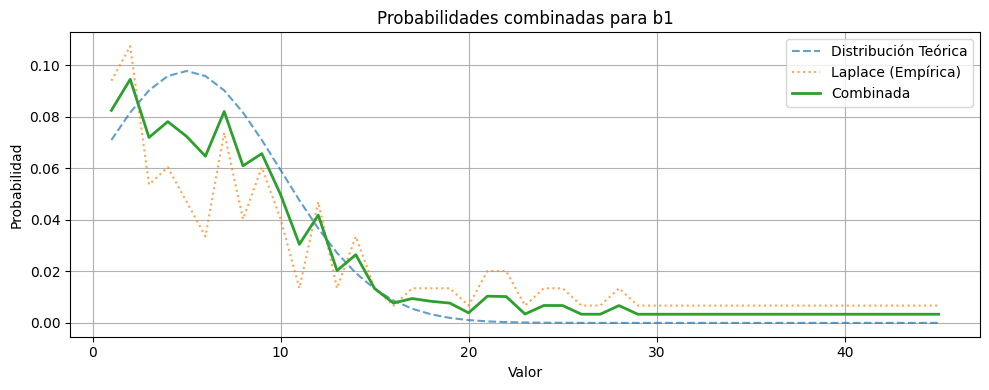

🎯 Siguientes valores más probables para b1:
  2: 0.0945
  1: 0.0825
  7: 0.0820
  4: 0.0781
  5: 0.0724
  3: 0.0720
  9: 0.0657
  6: 0.0647
  8: 0.0610
  10: 0.0498


In [370]:
b1_vals = next_gen_analyze("b1", body_size=104)

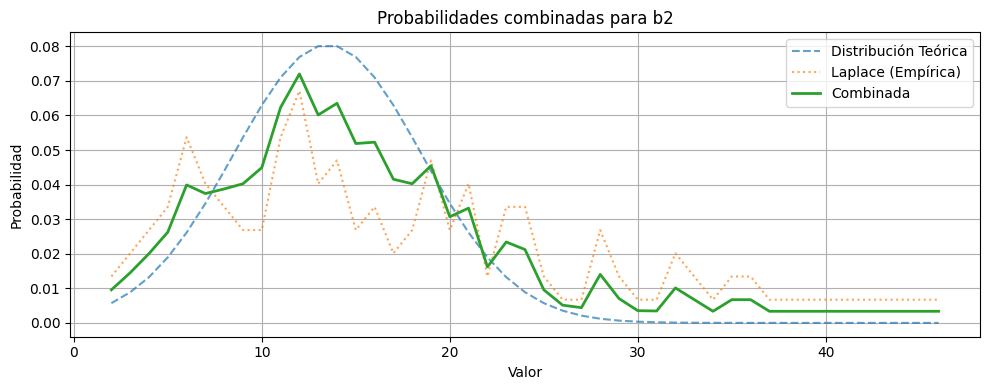

🎯 Siguientes valores más probables para b2:
  12: 0.0720
  14: 0.0635
  11: 0.0623
  13: 0.0602
  16: 0.0523
  15: 0.0519
  19: 0.0455
  10: 0.0449
  17: 0.0415
  9: 0.0402


In [371]:
b2_vals = next_gen_analyze("b2", body_size=104)

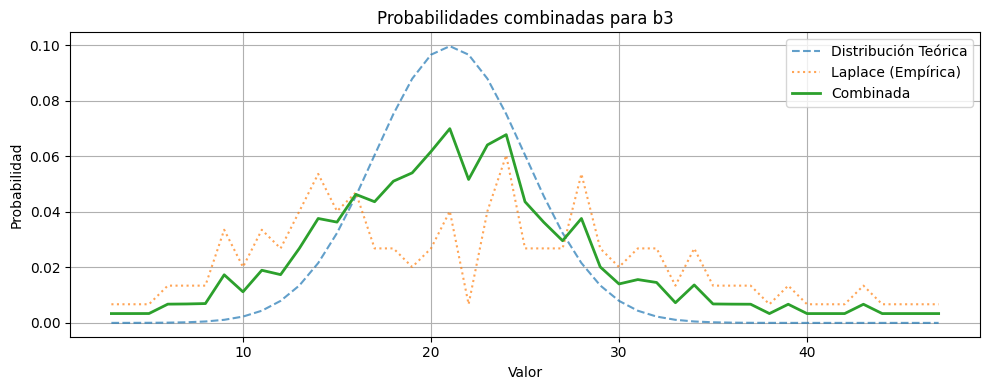

🎯 Siguientes valores más probables para b3:
  21: 0.0700
  24: 0.0678
  23: 0.0641
  20: 0.0618
  19: 0.0541
  22: 0.0517
  18: 0.0511
  16: 0.0463
  17: 0.0437
  25: 0.0437


In [372]:
b3_vals = next_gen_analyze("b3", body_size=104)

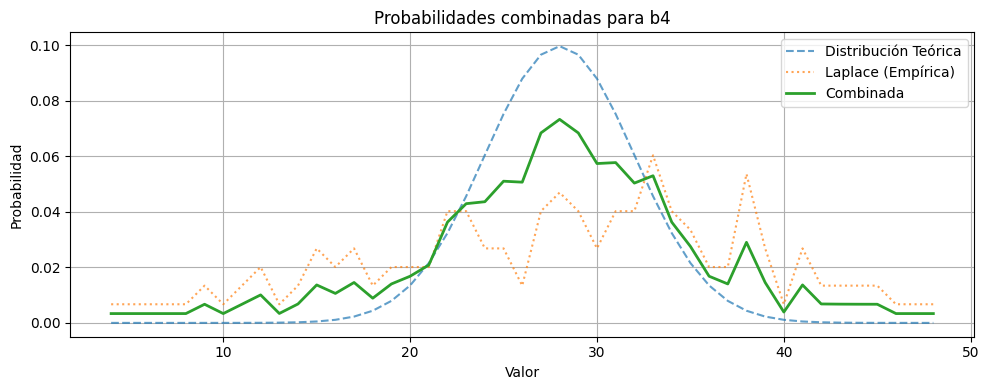

🎯 Siguientes valores más probables para b4:
  28: 0.0734
  27: 0.0685
  29: 0.0685
  31: 0.0578
  30: 0.0574
  33: 0.0530
  25: 0.0511
  26: 0.0507
  32: 0.0504
  24: 0.0437


In [373]:
b4_vals = next_gen_analyze("b4", body_size=104)

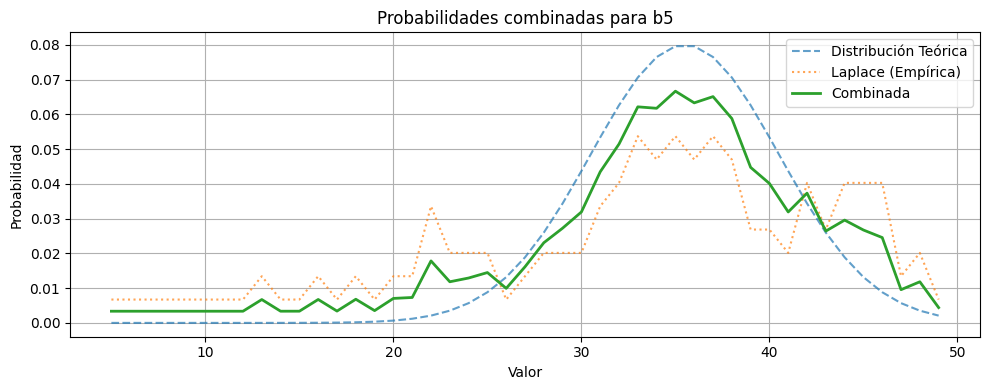

🎯 Siguientes valores más probables para b5:
  35: 0.0666
  37: 0.0651
  36: 0.0633
  33: 0.0621
  34: 0.0617
  38: 0.0588
  32: 0.0514
  39: 0.0447
  31: 0.0435
  40: 0.0401


In [374]:
b5_vals = next_gen_analyze("b5", body_size=104)

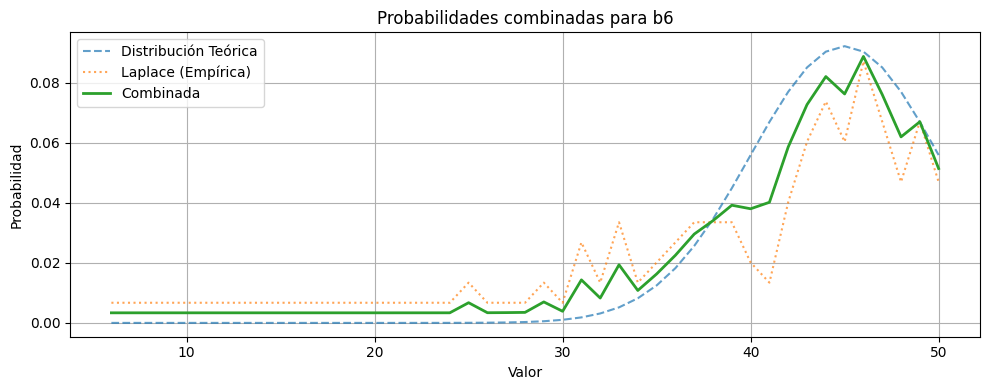

🎯 Siguientes valores más probables para b6:
  46: 0.0888
  44: 0.0821
  45: 0.0763
  47: 0.0761
  43: 0.0728
  49: 0.0671
  48: 0.0620
  42: 0.0587
  50: 0.0515
  41: 0.0402


In [375]:
b6_vals = next_gen_analyze("b6", body_size=104)